In [89]:
import pandas as pd
import requests
from bs4 import BeautifulSoup #used for webscrapping 

In [90]:
headers={'User-Agent':'Mozilla/5.0 (Windows NT 6.3; Win 64 ; x64) Apple WeKit /537.36(KHTML , like Gecko) Chrome/80.0.3987.162 Safari/537.36'}
web_page=requests.get('https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page=2',headers=headers).text

In [91]:
soup=BeautifulSoup(web_page,'lxml')

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script defer="" src="/static/js/env-runtime.js">
  </script>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   Top Companies in India | AmbitionBox
  </title>
  <meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content="1 day" data-n-head="ssr" name="revisit-a
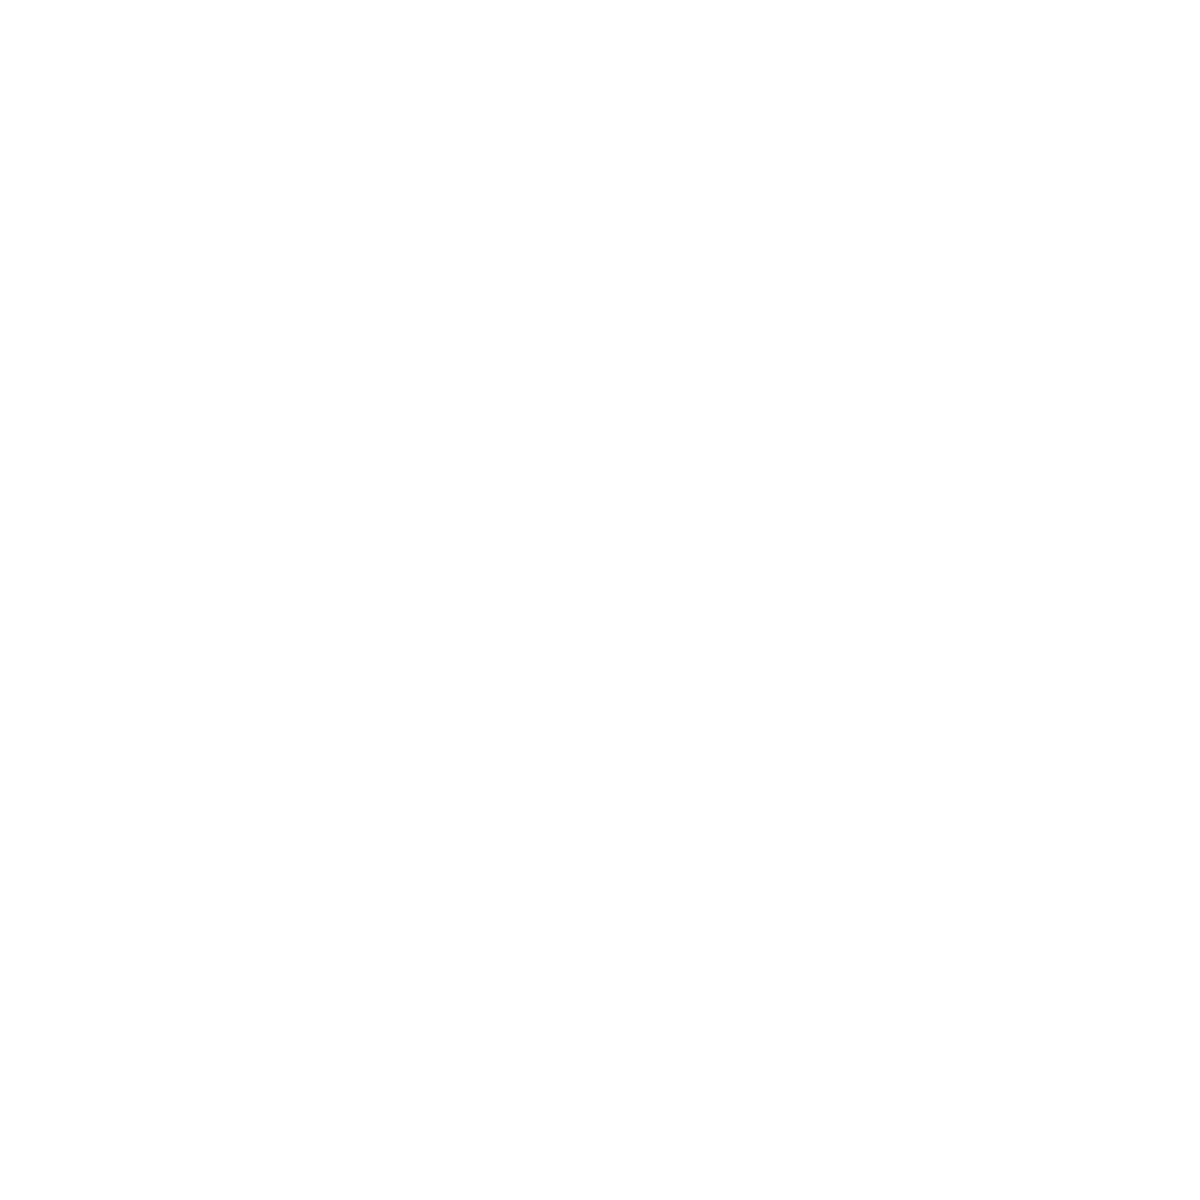

In [92]:
print(soup.prettify()) #it arranges the html file correctly

In [93]:
#finding all h1 tags in the webpages 
soup.find_all('h1')[0].text

'\n\t\t\t\t\tTop Companies in\n\t\t\t\t \n\t\t\t\t\tINDIA\n\t\t\t\t\t'

In [94]:
#finding all h2 tags 
soup.find_all('h2')

[<h2 class="companyListing__title">
 								Companies in India
 							</h2>,
 <h2 class="companyCardWrapper__companyName" title="HDB Financial Services">
 										HDB Financial Services
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Larsen &amp; Toubro Limited">
 										Larsen &amp; Toubro Limited
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Deloitte">
 										Deloitte
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Kotak Mahindra Bank">
 										Kotak Mahindra Bank
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Reliance Industries ">
 										Reliance Industries 
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Vodafone Idea">
 										Vodafone Idea
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="Bharti Airtel">
 										Bharti Airtel
 									</h2>,
 <h2 class="companyCardWrapper__companyName" title="BYJU'S">
 										BYJU'S
 									

In [95]:
len(soup.find_all('h2'))

24

In [96]:
#let's scrape the names of the companies 
ignore = [
    "Companies in India",
    "Popular Collections by Industries",
    "Popular Collections by Cities",
    "Popular Collections by Roles"
]
for i in soup.find_all("h2"):
    name = i.text.strip()
    if name not in ignore:
        print(name)
    

HDB Financial Services
Larsen & Toubro Limited
Deloitte
Kotak Mahindra Bank
Reliance Industries
Vodafone Idea
Bharti Airtel
BYJU'S
WNS
IDFC FIRST Bank
Ernst & Young
Tata Motors
IndusInd Bank
AU Small Finance Bank
Muthoot FinCorp
Bajaj Finserv
Flipkart
PwC
Mahindra & Mahindra
Infosys BPM


In [97]:
#let's extract the rating column
soup.find_all('div', class_= 'companyCardWrapper__companyRating')

[<div class="companyCardWrapper__companyRating"><div class="rating_star_container"><svg fill="none" height="20" viewbox="0 0 20 20" width="20" xmlns="http://www.w3.org/2000/svg"><rect fill="#9acd32" height="20" rx="4" width="20"></rect> <path d="M6.295 16L7.27 11.5632L4 8.57895L8.32 8.18421L10 4L11.68 8.18421L16 8.57895L12.73 11.5632L13.705 16L10 13.6474L6.295 16Z" fill="white"></path></svg> <div class="rating_text rating_text--md"><div style="height:auto;padding-bottom:1px;">
 			3.9<!-- --></div></div></div></div>,
 <div class="companyCardWrapper__companyRating"><div class="rating_star_container"><svg fill="none" height="20" viewbox="0 0 20 20" width="20" xmlns="http://www.w3.org/2000/svg"><rect fill="#9acd32" height="20" rx="4" width="20"></rect> <path d="M6.295 16L7.27 11.5632L4 8.57895L8.32 8.18421L10 4L11.68 8.18421L16 8.57895L12.73 11.5632L13.705 16L10 13.6474L6.295 16Z" fill="white"></path></svg> <div class="rating_text rating_text--md"><div style="height:auto;padding-bottom:1p

In [98]:
for i in soup.find_all('div', class_='companyCardWrapper__companyRating'):
    print(i.text.strip())

3.9
3.9
3.7
3.6
4.0
3.9
3.8
3.2
3.3
3.9
3.4
4.1
3.4
3.9
4.6
4.0
3.9
3.3
4.0
3.5


In [99]:
len(soup.find_all('div', class_= 'companyCardWrapper__companyRating'))

20

In [100]:
#let's extract the rating counts
soup.find_all('span',class_='companyCardWrapper__companyRatingCount')

[<span class="companyCardWrapper__companyRatingCount">
 									(25.4k)
 								</span>,
 <span class="companyCardWrapper__companyRatingCount">
 									(23.6k)
 								</span>,
 <span class="companyCardWrapper__companyRatingCount">
 									(22.7k)
 								</span>,
 <span class="companyCardWrapper__companyRatingCount">
 									(22.1k)
 								</span>,
 <span class="companyCardWrapper__companyRatingCount">
 									(20k)
 								</span>,
 <span class="companyCardWrapper__companyRatingCount">
 									(17.5k)
 								</span>,
 <span class="companyCardWrapper__companyRatingCount">
 									(17k)
 								</span>,
 <span class="companyCardWrapper__companyRatingCount">
 									(16.4k)
 								</span>,
 <span class="companyCardWrapper__companyRatingCount">
 									(15k)
 								</span>,
 <span class="companyCardWrapper__companyRatingCount">
 									(14.3k)
 								</span>,
 <span class="companyCardWrapper__companyRatingCount">
 									(14.2k)
 								</span>,
 <spa

In [101]:
for i in soup.find_all('span',class_='companyCardWrapper__companyRatingCount'):
    print(i.text.strip())
    

(25.4k)
(23.6k)
(22.7k)
(22.1k)
(20k)
(17.5k)
(17k)
(16.4k)
(15k)
(14.3k)
(14.2k)
(14.1k)
(14k)
(14k)
(13.1k)
(12.9k)
(12.8k)
(12.3k)
(11.9k)
(11.9k)


In [102]:
len(soup.find_all('span',class_='companyCardWrapper__companyRatingCount'))

20

In [103]:
#these above methods are for singleton function extraction and now we will focus on the companies divs only 

In [104]:
company=soup.find_all('div',class_='companyCardWrapper__primaryInformation')

In [105]:
len(company)

20

In [128]:
name=[]
rating=[]
review=[]
salaries=[]
for i in company:
    name.append((i.find('h2').text.strip()))
    rating.append(i.find('div',class_='companyCardWrapper__companyRating').text.strip())
    review.append(i.find('span',class_='companyCardWrapper__companyRatingCount').text.strip())
        
    

In [107]:
name

['HDB Financial Services',
 'Larsen & Toubro Limited',
 'Deloitte',
 'Kotak Mahindra Bank',
 'Reliance Industries',
 'Vodafone Idea',
 'Bharti Airtel',
 "BYJU'S",
 'WNS',
 'IDFC FIRST Bank',
 'Ernst & Young',
 'Tata Motors',
 'IndusInd Bank',
 'AU Small Finance Bank',
 'Muthoot FinCorp',
 'Bajaj Finserv',
 'Flipkart',
 'PwC',
 'Mahindra & Mahindra',
 'Infosys BPM']

In [108]:
rating

['3.9',
 '3.9',
 '3.7',
 '3.6',
 '4.0',
 '3.9',
 '3.8',
 '3.2',
 '3.3',
 '3.9',
 '3.4',
 '4.1',
 '3.4',
 '3.9',
 '4.6',
 '4.0',
 '3.9',
 '3.3',
 '4.0',
 '3.5']

In [109]:
review

['(25.4k)',
 '(23.6k)',
 '(22.7k)',
 '(22.1k)',
 '(20k)',
 '(17.5k)',
 '(17k)',
 '(16.4k)',
 '(15k)',
 '(14.3k)',
 '(14.2k)',
 '(14.1k)',
 '(14k)',
 '(14k)',
 '(13.1k)',
 '(12.9k)',
 '(12.8k)',
 '(12.3k)',
 '(11.9k)',
 '(11.9k)']

In [127]:
salaries

['0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0',
 '0']